# Math project

## Comparative Analysis of OLS, GLM Gamma, and Machine Learning Models: Theoretical Fit vs. Predictive Performance

### Objectives:
- **Understand** the theoretical assumptions and fit of Ordinary Least Squares (OLS) and Generalized Linear Model (GLM) Gamma regression.
- **Compare** the Mean Squared Error (MSE) and its standard deviation (stability) across OLS, GLM Gamma, and various machine learning models.
- **Interpret** the coefficients of OLS and GLM Gamma models, and **explore** how these interpretations differ.
- **Determine** which model should be chosen based on different objectives: theoretical understanding versus prediction accuracy.

By following the structured tasks and objectives in this notebook, you will develop a deeper understanding of the strengths and limitations of different regression models. Many times with real data you are faced with tradeoffs and the interpretation is subjective. Because of the subjectivity, a good discussion is sometimes more important than the final choice.

### Notebook Explanation and Task Framing

This notebook is designed to guide you through the process of understanding and comparing different regression models, focusing on their theoretical fit, predictive performance, and interpretation of results. The tasks are structured around four main objectives, each of which will help you build foundational knowledge in statistical modeling and machine learning. For the purpose of the assignment we are not going to deep into the technical aspects of the models, that is, we are not tunning hyperparameters and we are not doing feature engineering. The focus is on how to interpret the given results.

#### Objective 1: Understand Theoretical Assumptions and Fit
- **Task**: Start by running the provided code for Ordinary Least Squares (OLS) and Generalized Linear Model (GLM) Gamma regression.
  - **OLS**: Review the assumptions of OLS, including linearity, homoscedasticity, and normality of residuals. Consider how these assumptions might affect the fit of the model to different types of data.
  - **GLM Gamma**: Examine the assumptions of GLM Gamma, particularly its suitability for data that is skewed or heteroscedastic. Reflect on how these assumptions allow GLM Gamma to handle non-normal data distributions.

**Given Input**: You will be provided with the interpretation of the diagnostic plots for both OLS and GLM Gamma models.

- **Deliverable**:  
1. Based on the provided interpretations, decide which model (OLS or GLM Gamma) offers a better **theoretical** fit for the given data. Justify your decision by considering the alignment of model assumptions with the data structure.
2. Which model would you expect to be more flexible (i.e. more variance) and which one more biased?


#### Objective 2: Compare MSE and Stability
- **Task**: The provided code to perform cross-validation (CV) for OLS, GLM Gamma, and various machine learning models (e.g., Random Forest, Gradient Boosting, XGBoost, SVR).
  - Run the cross-validation for each model and collect the Mean Squared Error (MSE) and standard deviation of MSE across the folds.
  - Compare the results to understand which model provides better predictive accuracy (lower MSE) and which one demonstrates more stability (lower standard deviation of MSE).
- **Deliverable**: Summarize your findings by comparing the MSE and stability of each model. Discuss how the flexibility of a model might lead to higher variability in MSE (as seen in GLM Gamma, for example) and whether this trade-off is acceptable in your specific context. 

#### Objective 3: Interpret Coefficients
- **Task**: After running the OLS and GLM Gamma models, closely examine the coefficients generated by each model.
  - For OLS: Understand how to interpret the coefficients assuming linear relationships between the predictors and the target variable.
  - For GLM Gamma: Consider how the coefficients are interpreted differently due to the link function and distribution assumptions.
- **Deliverable**: Provide an interpretation of the coefficients for both OLS and GLM Gamma models. Discuss the implications of these interpretations, especially how they might differ due to the underlying model assumptions. This will help in understanding how the choice of model affects the conclusions drawn from the data.

#### Objective 4: Determine the Best Model for Your Objective
- **Task**: With the knowledge gained from the previous objectives, critically evaluate which model is best suited for different objectives.
  - If the goal is theoretical understanding and interpretation, consider the fit and interpretability of OLS and GLM Gamma.
  - If the goal is prediction accuracy, focus on the models with the lowest MSE and highest stability from the cross-validation results.
- **Deliverable**: Conclude with an explicit (not fuzzy) recommendation on which model to use based on the specific objective at hand—whether it's gaining theoretical insights from the data or making accurate predictions. Provide a rationale for your choice, considering both the theoretical fit and the predictive performance.


**Markdown cells are provided for you to enter your deliverables. Submit a pdf version of the notebook with your answers in the provided cells.**

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



# Load the data
data = pd.read_csv('insurance.csv')

# Define the columns
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)])

# Preprocess the features
X = preprocessor.fit_transform(data)

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Define the dependent variable
y = data['charges']

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Print the model summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Wed, 04 Sep 2024   Prob (F-statistic):               0.00
Time:                        17:07:20   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9053.4925    386.149     23.446      0.0

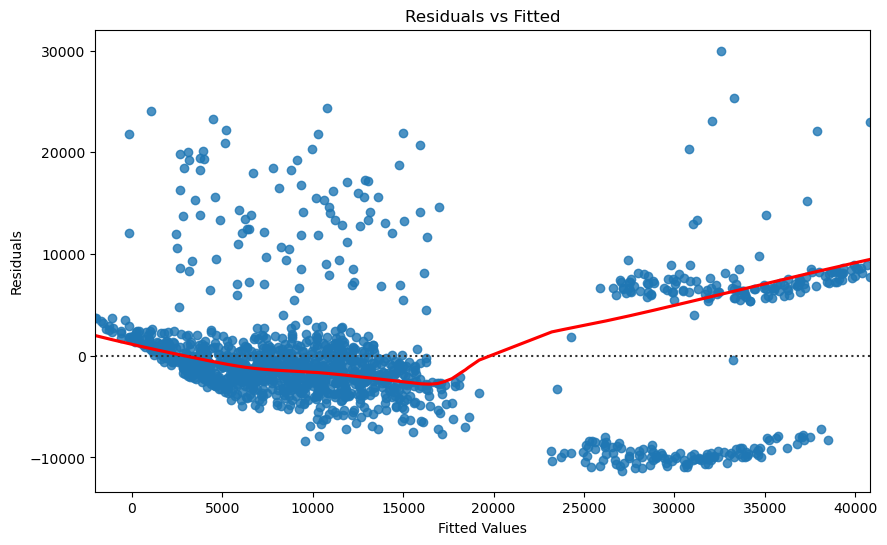

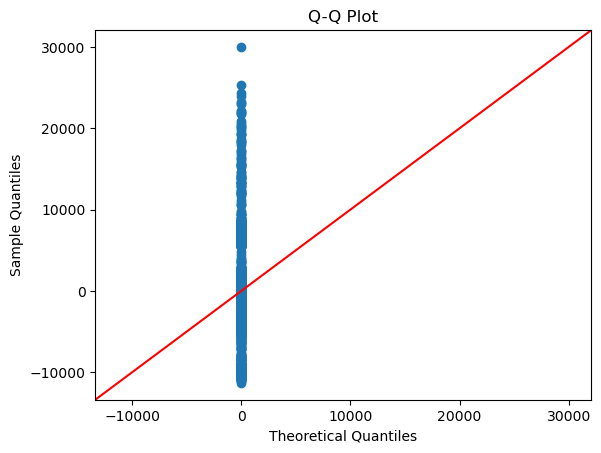

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


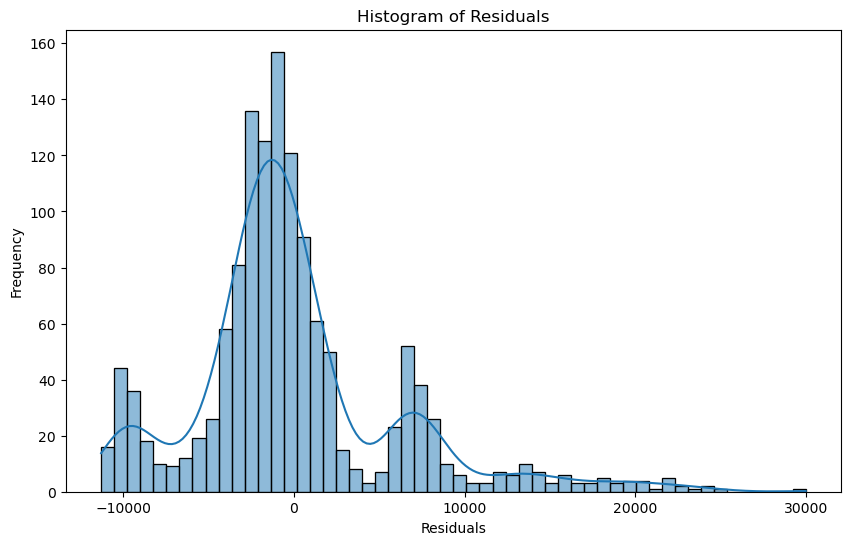

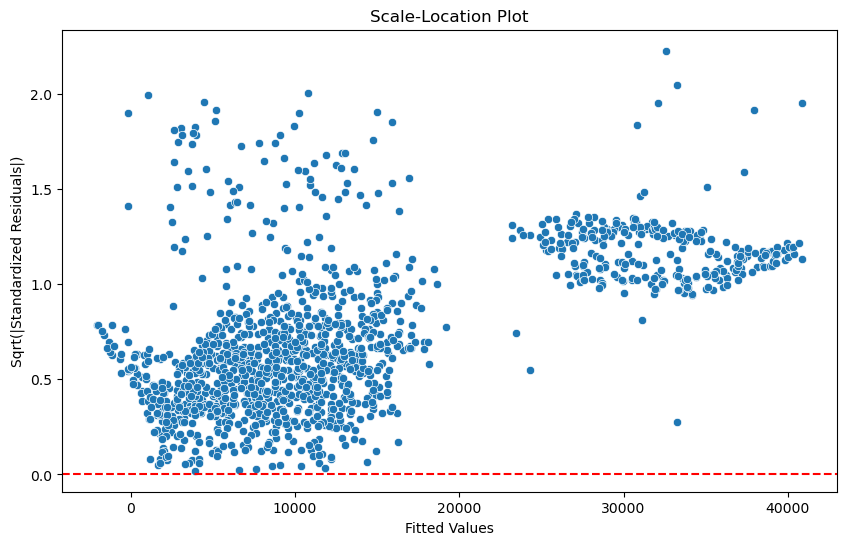

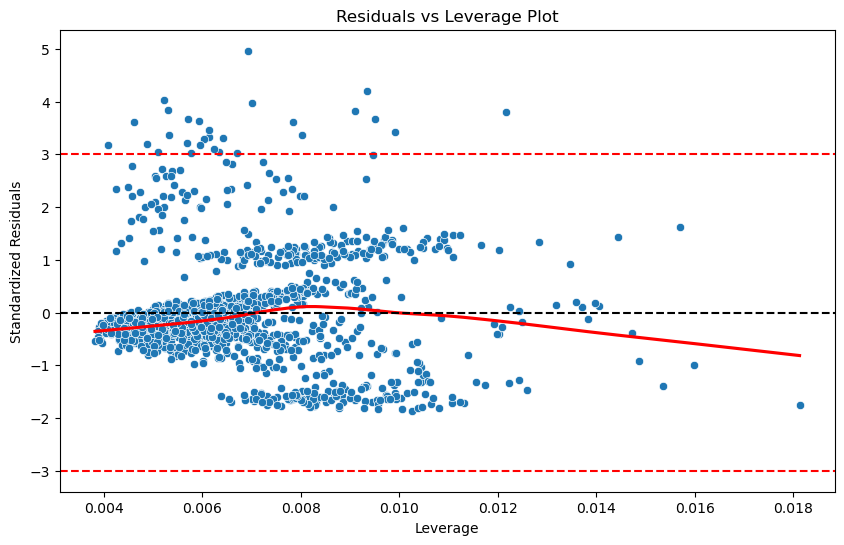

In [2]:
# Get the fitted values and residuals
fitted_vals = model.fittedvalues
residuals = model.resid
standardized_residuals = model.get_influence().resid_studentized_internal
leverage = model.get_influence().hat_matrix_diag

# Residuals vs Fitted plot
plt.figure(figsize=(10, 6))
sns.residplot(x=fitted_vals, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# Q-Q plot of residuals
sm.qqplot(residuals, line='45')
plt.title('Q-Q Plot')
plt.show()

# Histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Scale-Location plot (Square root of standardized residuals vs. fitted values)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=np.sqrt(np.abs(standardized_residuals)))
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Sqrt(|Standardized Residuals|)')
plt.title('Scale-Location Plot')
plt.show()

# Residuals vs Leverage plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=leverage, y=standardized_residuals)
sns.regplot(x=leverage, y=standardized_residuals,
            scatter=False, ci=None, lowess=True, line_kws={'color': 'red'})
plt.axhline(0, color='black', linestyle='--')
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Standardized Residuals')
plt.title('Residuals vs Leverage Plot')
plt.show()

### Interpretation of OLS Diagnostic Plots

1. **Residuals vs. Fitted Values Plot**:
   - **What it shows**: This plot is used to check for non-linearity and heteroscedasticity. The residuals should be randomly scattered around the horizontal line (y=0) without any systematic patterns.
   - **Interpretation**: In the plot, there appears to be a non-random pattern with residuals curving downward for lower fitted values and upward for higher fitted values. This suggests that the model might not be capturing all the relationships in the data (possible non-linearity), and there is evidence of heteroscedasticity (variance of residuals increasing with fitted values).

2. **Q-Q Plot**:
   - **What it shows**: This plot compares the quantiles of the residuals to the quantiles of a standard normal distribution. If the residuals are normally distributed, the points should lie on the red diagonal line.
   - **Interpretation**: The Q-Q plot shows that the residuals deviate significantly from the diagonal line, especially in the tails. This suggests that the residuals are not normally distributed, which is a violation of one of the OLS assumptions.

3. **Histogram of Residuals**:
   - **What it shows**: This histogram provides another check for normality. The distribution should resemble a bell curve if the residuals are normally distributed.
   - **Interpretation**: The histogram of residuals suggests that they are not normally distributed, as indicated by the skewness and multiple peaks. This again indicates that the normality assumption is violated.

4. **Scale-Location Plot**:
   - **What it shows**: Also known as the spread-location plot, this plot checks for homoscedasticity (equal variance of residuals across all levels of the fitted values). The red line should be horizontal, and the points should be evenly distributed along it.
   - **Interpretation**: The plot shows a funnel shape, with the spread of the residuals increasing with the fitted values. This is a sign of heteroscedasticity, meaning the variance of the residuals is not constant.

5. **Residuals vs. Leverage Plot**:
   - **What it shows**: This plot identifies influential observations that could disproportionately affect the regression results. Points outside the red dashed lines are considered potentially influential.
   - **Interpretation**: There are some points with high leverage, but none seem to have both high leverage and large standardized residuals (greater than 3 or less than -3). However, the overall pattern in the plot may still suggest some influential points, though they are not extreme.

### Summary of Issues:
- **Non-Linearity**: The residuals vs. fitted plot indicates potential non-linearity in the data, suggesting that the OLS model might not be the best fit.
- **Heteroscedasticity**: Both the residuals vs. fitted plot and the scale-location plot suggest heteroscedasticity, violating one of the key assumptions of OLS.
- **Non-Normality of Residuals**: The Q-Q plot and histogram show that the residuals are not normally distributed.

In [3]:
import statsmodels.api as sm

# Fit the GLM model with Gamma family and Log link
glm_gamma_model = sm.GLM(y, X, family=sm.families.Gamma(link=sm.families.links.Log())).fit()

# Print the model summary
print(glm_gamma_model.summary())



                 Generalized Linear Model Regression Results                  
Dep. Variable:                charges   No. Observations:                 1338
Model:                            GLM   Df Residuals:                     1329
Model Family:                   Gamma   Df Model:                            8
Link Function:                    Log   Scale:                         0.46695
Method:                          IRLS   Log-Likelihood:                -13307.
Date:                Wed, 04 Sep 2024   Deviance:                       337.73
Time:                        17:07:20   Pearson chi2:                     621.
No. Iterations:                    18   Pseudo R-squ. (CS):             0.6833
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.0344      0.044    207.554      0.0

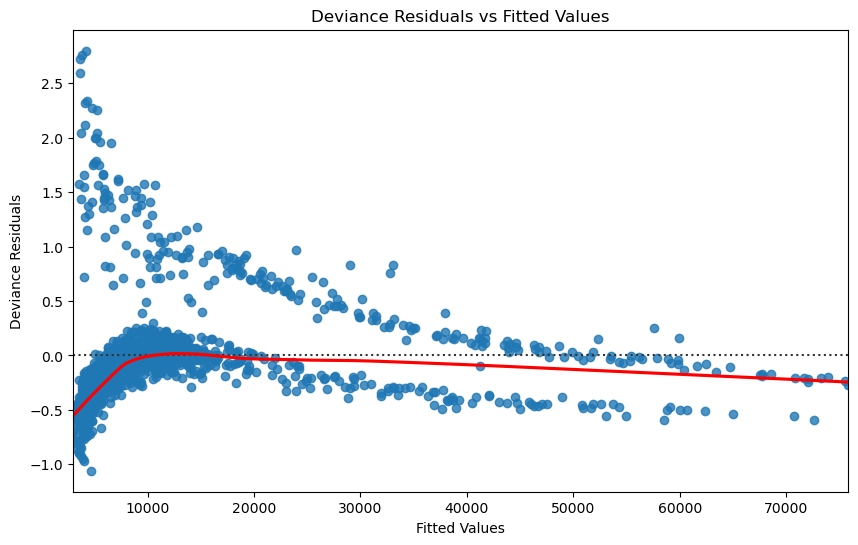

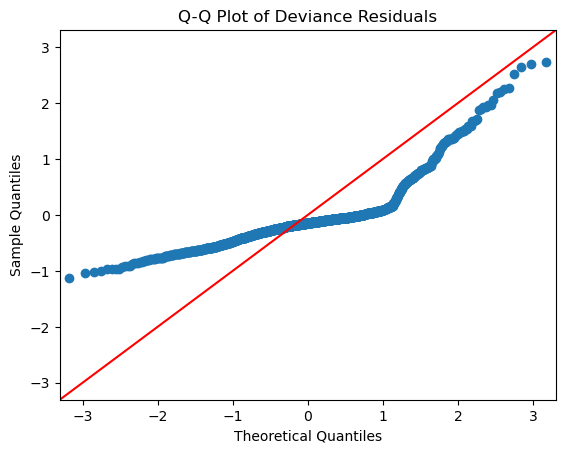

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


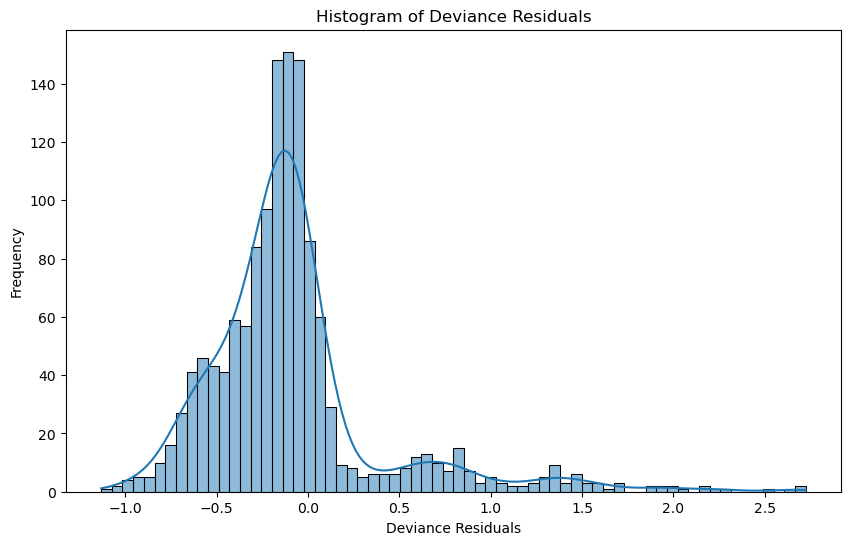

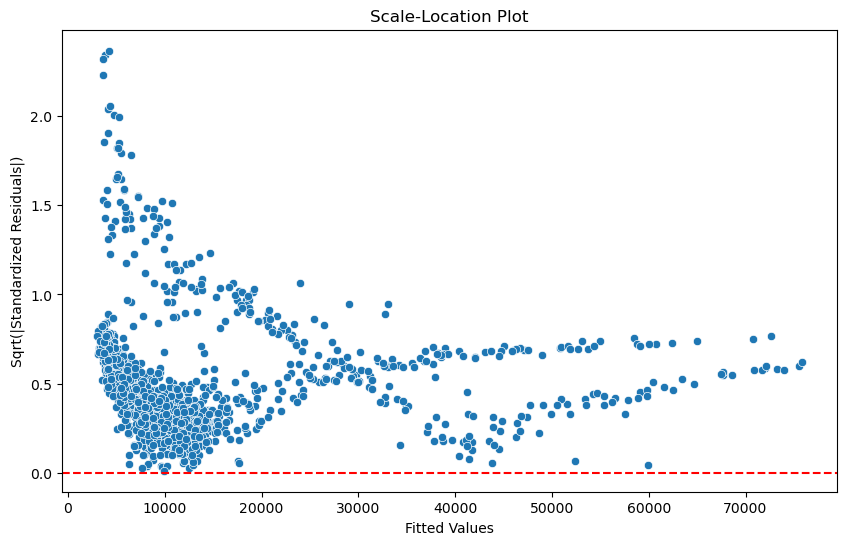

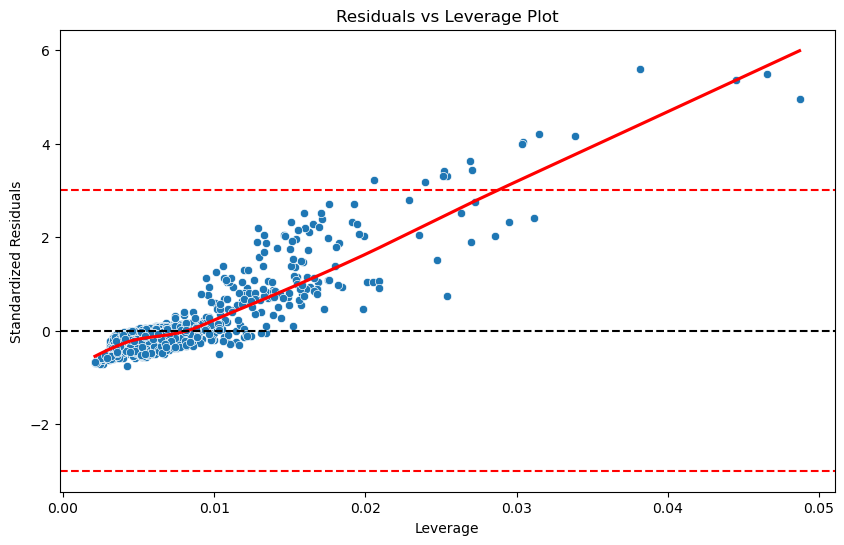

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Calculate fitted values, deviance residuals, and other diagnostics
fitted_vals = glm_gamma_model.fittedvalues
deviance_residuals = glm_gamma_model.resid_deviance
standardized_residuals = glm_gamma_model.resid_pearson
leverage = glm_gamma_model.get_influence().hat_matrix_diag

# Residuals vs Fitted plot
plt.figure(figsize=(10, 6))
sns.residplot(x=fitted_vals, y=deviance_residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted Values')
plt.ylabel('Deviance Residuals')
plt.title('Deviance Residuals vs Fitted Values')
plt.show()

# Q-Q plot of deviance residuals
sm.qqplot(deviance_residuals, line='45')
plt.title('Q-Q Plot of Deviance Residuals')
plt.show()

# Histogram of deviance residuals
plt.figure(figsize=(10, 6))
sns.histplot(deviance_residuals, kde=True)
plt.title('Histogram of Deviance Residuals')
plt.xlabel('Deviance Residuals')
plt.ylabel('Frequency')
plt.show()

# Scale-Location plot (Square root of standardized residuals vs. fitted values)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=np.sqrt(np.abs(standardized_residuals)))
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Sqrt(|Standardized Residuals|)')
plt.title('Scale-Location Plot')
plt.show()

# Residuals vs Leverage plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=leverage, y=standardized_residuals)
sns.regplot(x=leverage, y=standardized_residuals,
            scatter=False, ci=None, lowess=True, line_kws={'color': 'red'})
plt.axhline(0, color='black', linestyle='--')
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.xlabel('Leverage')
plt.ylabel('Standardized Residuals')
plt.title('Residuals vs Leverage Plot')
plt.show()


### Interpretation of GLM Gamma Diagnostic Plots

1. **Deviance Residuals vs. Fitted Values Plot**:
   - **What it shows**: This plot is used to check for systematic patterns in the residuals, which might indicate issues with the model fit, such as non-linearity or incorrect specification of the link function.
   - **Interpretation**: The plot shows a decreasing trend in residuals as fitted values increase, particularly for lower fitted values. While the pattern suggests some non-linearity, this trend is less pronounced compared to the OLS model. There is still some heteroscedasticity, but the overall spread of residuals is more evenly distributed, indicating some improvement over the OLS model.

2. **Q-Q Plot of Deviance Residuals**:
   - **What it shows**: This plot checks whether the residuals follow the expected theoretical distribution, which in the case of a Gamma GLM, should show a reasonable fit to the Gamma distribution.
   - **Interpretation**: The Q-Q plot shows some deviation from the line, particularly in the tails, suggesting that the residuals are not perfectly following the expected distribution. However, the fit is better than what was observed in the OLS Q-Q plot, especially around the center of the distribution.

3. **Histogram of Deviance Residuals**:
   - **What it shows**: This histogram visualizes the distribution of the deviance residuals. For a well-fitting Gamma GLM, we might expect a skewed distribution consistent with the Gamma distribution.
   - **Interpretation**: The histogram shows a skewed distribution of residuals, which aligns with the expectations for a Gamma model. There is a notable improvement in the residuals' distribution compared to the OLS model, which had a more irregular shape.

4. **Scale-Location Plot**:
   - **What it shows**: This plot assesses the homoscedasticity of the residuals. In a good model, the residuals should be randomly scattered around a horizontal line without any clear pattern.
   - **Interpretation**: The plot shows a more consistent spread of residuals across the range of fitted values, although there is still some decrease in residuals' variability as the fitted values increase. This indicates that heteroscedasticity is still present but is less severe than in the OLS model.

5. **Residuals vs. Leverage Plot**:
   - **What it shows**: This plot identifies influential observations that could disproportionately affect the model fit.
   - **Interpretation**: The plot shows some points with high leverage and high standardized residuals, indicating a few potentially influential observations. The linear trend in the plot suggests that leverage is still an issue, but it is more aligned with the expected behavior in a GLM context, as opposed to the more problematic leverage issues seen in the OLS model.

#### Objective 1: Understand Theoretical Assumptions and Fit

- **Deliverable**:  
1. Based on the provided interpretations, decide which model (OLS or GLM Gamma) offers a better **theoretical** fit for the given data. Justify your decision by considering the alignment of model assumptions with the data structure.
2. Which model would you expect to be more flexible (i.e. more variance) and which one more biased?

#### Answer: 

1. Based on the interpretations and plots, the GLM Gamma model offers a better theoretical fit than the OLS model. The OLS model requires five key assumptions, but three of these assumptions were violated: linearity, the normal distribution of residuals, and homoscedasticity. In contrast, the GLM Gamma model, despite showing some non-linearity in the link function, demonstrates a more evenly distributed spread of residuals compared to the OLS model. Additionally, the skewed distribution in the histogram suggests a significant improvement over OLS. To conclude, after reviewing the interpretations and plots, the GLM Gamma model is theoretically a better fit for the given data.

2. The GLM Gamma model is more flexible because it doesn’t require normally distributed errors or homoscedasticity and can model different relationships by adjusting the link functions. On the other hand, the OLS model is more biased because it violates several key OLS assumptions, particularly non-normality, heteroscedasticity, and non-linearity. These violations suggest that the OLS model might systematically underfit the data, leading to higher bias.

# Cross-Validation with OLS

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the OLS model using scikit-learn's LinearRegression
ols_model = LinearRegression()

# Define a KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores_ols = []
r2_scores_ols = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    ols_model.fit(X_train, y_train)
    
    # Predict
    y_pred = ols_model.predict(X_test)
    
    # Calculate MSE and R2
    mse_scores_ols.append(mean_squared_error(y_test, y_pred))
    r2_scores_ols.append(r2_score(y_test, y_pred))

# Display the individual MSE and R2 scores
for i, (mse, r2) in enumerate(zip(mse_scores_ols, r2_scores_ols)):
    print(f"Fold {i+1} - OLS MSE: {mse:.4f}, R2: {r2:.4f}")

# Calculate the mean and standard deviation
mean_mse_ols = np.mean(mse_scores_ols)
std_mse_ols = np.std(mse_scores_ols)
mean_r2_ols = np.mean(r2_scores_ols)
std_r2_ols = np.std(r2_scores_ols)

print(f"\nOLS Mean MSE: {mean_mse_ols:.4f}, Std MSE: {std_mse_ols:.4f}")
print(f"OLS Mean R2: {mean_r2_ols:.4f}, Std R2: {std_r2_ols:.4f}")


Fold 1 - OLS MSE: 33596915.8514, R2: 0.7836
Fold 2 - OLS MSE: 37439620.2261, R2: 0.7380
Fold 3 - OLS MSE: 33451562.8555, R2: 0.7956
Fold 4 - OLS MSE: 41559312.1077, R2: 0.6324
Fold 5 - OLS MSE: 38946008.5367, R2: 0.7513

OLS Mean MSE: 36998683.9155, Std MSE: 3128575.4360
OLS Mean R2: 0.7402, Std R2: 0.0578


# Cross-Validation with GLM Gamma

In [6]:
from sklearn.base import BaseEstimator, RegressorMixin
import statsmodels.api as sm

# Custom wrapper to make GLM Gamma compatible with scikit-learn's cross_val_score
class GLMGammaWrapper(BaseEstimator, RegressorMixin):
    def __init__(self):
        self.model = None
    
    def fit(self, X, y):
        self.model = sm.GLM(y, X, family=sm.families.Gamma(link=sm.families.links.Log())).fit()
        return self
    
    def predict(self, X):
        return self.model.predict(X)

# Initialize the GLM Gamma wrapper
glm_gamma_model = GLMGammaWrapper()

mse_scores_glm = []
r2_scores_glm = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    glm_gamma_model.fit(X_train, y_train)
    
    # Predict
    y_pred = glm_gamma_model.predict(X_test)
    
    # Calculate MSE and R2
    mse_scores_glm.append(mean_squared_error(y_test, y_pred))
    r2_scores_glm.append(r2_score(y_test, y_pred))

# Display the individual MSE and R2 scores
for i, (mse, r2) in enumerate(zip(mse_scores_glm, r2_scores_glm)):
    print(f"Fold {i+1} - GLM Gamma MSE: {mse:.4f}, R2: {r2:.4f}")

# Calculate the mean and standard deviation
mean_mse_glm = np.mean(mse_scores_glm)
std_mse_glm = np.std(mse_scores_glm)
mean_r2_glm = np.mean(r2_scores_glm)
std_r2_glm = np.std(r2_scores_glm)

print(f"\nGLM Gamma Mean MSE: {mean_mse_glm:.4f}, Std MSE: {std_mse_glm:.4f}")
print(f"GLM Gamma Mean R2: {mean_r2_glm:.4f}, Std R2: {std_r2_glm:.4f}")


Fold 1 - GLM Gamma MSE: 53385412.8412, R2: 0.6561
Fold 2 - GLM Gamma MSE: 47845202.3086, R2: 0.6652
Fold 3 - GLM Gamma MSE: 67711267.5039, R2: 0.5862
Fold 4 - GLM Gamma MSE: 65556224.5077, R2: 0.4202
Fold 5 - GLM Gamma MSE: 72881885.8010, R2: 0.5346

GLM Gamma Mean MSE: 61475998.5925, Std MSE: 9347483.8332
GLM Gamma Mean R2: 0.5725, Std R2: 0.0899


### Understanding the Apparent Contradiction Between Diagnostic Plots and Cross-Validation Results

1. **Diagnostic Plots vs. Predictive Performance**:
   - **Diagnostic Plots**: Assess how well a model fits the data by examining assumptions like normality, homoscedasticity, and linearity. The GLM Gamma model showed a better theoretical fit, handling skewness, non-linearity, and heteroscedasticity better than the OLS model.
   - **Cross-Validation**: Focuses on evaluating a model's predictive performance on unseen data. It measures overall error (MSE) and explained variance $( R^2 )$ but doesn't directly assess the model's assumptions.

2. **Model Fit vs. Predictive Power**:
   - The GLM Gamma model aligns better with the data's characteristics theoretically but may not always perform better in predictive accuracy.
   - The OLS model, despite some assumption violations, might predict new data better if the underlying relationships are predominantly linear. CV results suggest that the linear approximation of the OLS model is closer to the actual values than the GLM Gamma model's predictions.

3. **Bias-Variance Tradeoff**:
   - The OLS model benefits from lower variance due to its simpler assumptions, leading to more stable predictions across different folds.
   - The GLM Gamma model, while better suited to the data's distribution, might introduce more variance due to its flexibility, resulting in less stable predictions and higher MSE in cross-validation.

4. **Practical vs. Theoretical Fit**:
   - A model that fits the data well theoretically might not always outperform a simpler model like OLS in predictive tasks. The OLS model's better performance in CV suggests that linear relationships dominate in this dataset, and the added complexity of the GLM Gamma model does not improve generalization.

**Conclusion**:
While the GLM Gamma model provides a better theoretical fit by addressing skewness and heteroscedasticity, the OLS model outperforms it in predictive accuracy as measured by cross-validation. This highlights the importance of using multiple evaluation methods: diagnostic plots for model selection based on data characteristics, and cross-validation for assessing predictive performance on unseen data. The OLS model's simpler, linear nature appears to capture the dominant relationships better, leading to superior predictive performance despite some theoretical shortcomings.


# Random Forest

In [7]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Initialize the RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf_regressor, X, y, cv=5, scoring='neg_mean_squared_error')

# Calculate the mean and standard deviation of the cross-validated scores
mean_cv_score = np.mean(-cv_scores)
std_cv_score = np.std(-cv_scores)

print(f"Random Forest Mean Cross-Validated MSE: {mean_cv_score:.4f}")
print(f"Random Forest Standard Deviation of CV MSE: {std_cv_score:.4f}")


Random Forest Mean Cross-Validated MSE: 23762058.3507
Random Forest Standard Deviation of CV MSE: 3348331.2515


# Gradient Boosting

In [8]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# Initialize the GradientBoostingRegressor
gb_regressor = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Perform 5-fold cross-validation and calculate MSE
mse_scores_gb = cross_val_score(gb_regressor, X, y, cv=5, scoring='neg_mean_squared_error')

# Calculate the mean and standard deviation of the cross-validated MSE scores
mean_mse_gb = -mse_scores_gb.mean()  # Negate because cross_val_score returns negative MSE
std_mse_gb = mse_scores_gb.std()

print(f"Gradient Boosting Mean MSE: {mean_mse_gb:.4f}")
print(f"Gradient Boosting Standard Deviation of MSE: {std_mse_gb:.4f}")


Gradient Boosting Mean MSE: 21000252.6343
Gradient Boosting Standard Deviation of MSE: 3407462.4637


### XGBoost

In [9]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score

# Initialize the XGBoost Regressor
xgb_regressor = xgb.XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')

# Perform 5-fold cross-validation and calculate MSE
mse_scores_xgb = cross_val_score(xgb_regressor, X, y, cv=5, scoring='neg_mean_squared_error')

# Calculate the mean and standard deviation of the cross-validated MSE scores
mean_mse_xgb = -mse_scores_xgb.mean()  # Negate because cross_val_score returns negative MSE
std_mse_xgb = mse_scores_xgb.std()

print(f"XGBoost Mean MSE: {mean_mse_xgb:.4f}")
print(f"XGBoost Standard Deviation of MSE: {std_mse_xgb:.4f}")


XGBoost Mean MSE: 27935903.1509
XGBoost Standard Deviation of MSE: 3481893.3864


In [10]:
from sklearn.svm import SVR

svr_regressor = SVR(kernel='rbf', C=1.0, epsilon=0.1)
mse_scores_svr = cross_val_score(svr_regressor, X, y, cv=5, scoring='neg_mean_squared_error')
mean_mse_svr = -mse_scores_svr.mean()
std_mse_svr = mse_scores_svr.std()

print(f"SVR Mean MSE: {mean_mse_svr:.4f}")
print(f"SVR Standard Deviation of MSE: {std_mse_svr:.4f}")


SVR Mean MSE: 161477701.4976
SVR Standard Deviation of MSE: 9943594.8448


#### Objective 2: Compare MSE and Stability

- **Deliverable**: Summarize your findings by comparing the MSE and stability of each model. Discuss how the flexibility of a model might lead to higher variability in MSE (as seen in GLM Gamma, for example) and whether this trade-off is acceptable in your specific context. 


#### Answer: 

- **Summarize**: 
    - **OLS**: The OLS model performs well with a reasonable MSE and low standard deviation, which suggests that although the dataset theoretically violates the assumptions of linearity, homoscedasticity, and normality, OLS still outperforms GLM. This indicates that the underlying relationships are better captured by OLS, and despite the shape of the dataset, there is still some linear relationship between the variables. This makes OLS more effective in this case than expected.
    - **GLM**: While GLM is more flexible due to its ability to model non-linear relationships and handle skewed data, its higher MSE and lower R-squared indicate that it underperforms, especially when compared to OLS. Additionally, the higher variability across different folds suggests that it may be overfitting or struggling with noise, potentially capturing unnecessary relationships that don’t generalize well.
    - **Random Forest**: Random Forest achieves both low MSE and standard deviation, suggesting that it not only makes more accurate predictions but also maintains stability across different folds. For this dataset, Random Forest outperforms statistical models due to its ability to capture complex, non-linear relationships while being robust to overfitting through its ensemble methods. 
    - **Gradient Boosting**: Gradient Boosting shows slightly lower MSE but higher standard deviation compared to Random Forest. This means that while it is more accurate in some cases, it may be slightly less stable compared to Random Forest. However, with its much lower MSE and only slightly higher variability compared to OLS, it still outperforms statistical models overall.
    - **XGBoost**: XGBoost has both a slightly higher MSE and standard deviation compared to Random Forest but still outperforms the statistical models. XGBoost’s ability to handle complex datasets makes it powerful, but for this particular dataset and with the current hyperparameters, Random Forest or Gradient Boosting might be the better choice due to its balance of accuracy and stability.
    - **SVR**: SVR achieves the lowest MSE, which indicates that it makes the most accurate predictions. However, the extremely high standard deviation suggests that it is very unstable, and its performance may vary significantly across different folds or datasets. This could indicate that SVR is overfitting or being strongly affected by outliers with the current hyperparameter settings. As a result, SVR might require further tuning to reduce its variability and improve generalization.

- **Flexibility and variability**: The GLM Gamma model is more flexible, as it does not require a linear relationship and can handle skewed data distributions. However, this higher flexibility comes with greater variability, suggesting potential overfitting in some cases or that the model is being misled by outliers or noise, capturing unnecessary relationships.

- **Trade-off**: Since this dataset focuses on insurance and the determination of premiums, the accuracy and stability of the model are critical to avoid financial risk and remain competitive in the market. Therefore, if choosing only between the statistical models, the OLS model is preferred despite its simpler structure, as it provides more accurate predictions and greater robustness. However, when considering all models, the Gradient Boosting model stands out due to its balance between accuracy and reasonable stability. While it is more complex than OLS, it offers significantly better performance in terms of predictive power, making it the ideal choice in this context.


#### Objective 3: Interpret Coefficients

- **Deliverable**: Provide an interpretation of the coefficients for both OLS and GLM Gamma models. Discuss the implications of these interpretations, especially how they might differ due to the underlying model assumptions. This will help in understanding how the choice of model affects the conclusions drawn from the data.

Tip: how to convert the GLM Gamma model output to the original variables is covered in the Individual Assignment 5.

In [11]:
## Re-define the GLM Gamma model

# Load the data
data = pd.read_csv('insurance.csv')

# Define the columns
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)])

# Preprocess the features
X = preprocessor.fit_transform(data)

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Define the dependent variable
y = data['charges']

# Fit the GLM model with Gamma family and Log link
glm_gamma_model = sm.GLM(y, X, family=sm.families.Gamma(link=sm.families.links.Log())).fit()

## Transform the coefficients to the original scale
glm_coefficients = glm_gamma_model.params
transformed_coefficients = np.exp(glm_coefficients)

print("Transformed GLM Coefficients:")
print(np.round(transformed_coefficients, 4))

Transformed GLM Coefficients:
const    8386.5694
x1          1.4951
x2          1.0899
x3          1.1068
x4          0.9445
x5          4.4832
x6          0.9438
x7          0.8679
x8          0.8646
dtype: float64


#### Answer 
- x1 (age): 
    - OLS: With each additional year of age, the insurance charge increases by approximately $3607.47. This suggests that younger people tend to have significantly lower premium fees.
    - GLM: With each additional year of age, the insurance charge increases by about 49.51%. This also suggests that younger people would receive lower quotes, but the increase in charges with age is less drastic compared to the OLS model.
- x2 (BMI) 
    - OLS: For each one-unit increase in BMI, the insurance charge increases by approximately $2067.69. This suggests that individuals with potential weight issues would face much higher premium fees.
    - GLM: For each one-unit increase in BMI, the insurance charge increases by about 8.99%. This also indicates that weight issues are a consideration, but the impact on charges is much smaller compared to the OLS model.
- x3 (children): 
    - OLS: With each additional child in the household, the insurance charge increases by approximately $572.99. This aligns with the understanding that families with children may face more stressful problems, potentially leading to higher healthcare costs.
    - GLM: With each additional child in the household, the insurance charge increases by about 10.68%. This similarly suggests that having more children increases the premium by around 10% per child.
- x4 (sex): This is a categorical variable, where 0 represents female and 1 represents male.
    - OLS: The OLS model does not find this variable significant, with a p-value of 0.693 (greater than the 0.05 threshold). This suggests there is no strong evidence that gender affects the insurance premium.
    - GLM: The GLM model also does not find this variable significant, with a p-value of 0.128 (greater than the 0.05 threshold). This similarly suggests there is no strong evidence that gender affects the insurance premium.
- x5 (smoker): This is a categorical variable, where 0 represents non-smokers and 1 represents smokers.
    - OLS: The insurance charge for smokers is approximately $23,805.44 higher than for non-smokers, which aligns with the common understanding that smokers have a higher risk of illness. Additionally, this variable has the largest magnitude, indicating that the OLS model considers smoking status to be the most important factor in determining insurance charges.
    - GLM: The insurance charge for smokers increases by about 348.32%. Like the OLS model, the GLM model also considers smoking status to be the most significant characteristic in determining insurance charges.
- x6, x7, x8 (region): x6, x7, and x8 together represent the categorical variable “region,” with (0, 0, 0) for Northeast (the baseline), (1, 0, 0) for Northwest, (0, 1, 0) for Southeast, and (0, 0, 1) for Southwest.
    - OLS: The OLS model finds that x6 (Northwest) is not significant, but x7 (Southeast) and x8 (Southwest) have a negative effect on the insurance premium, with magnitudes of approximately -$1035.02 and -$960.05, respectively, compared to the Northeast (the baseline).
    - GLM: The GLM model also finds that x6 (Northwest) is not significant (p-value = 0.281). However, it finds that x7 (Southeast) and x8 (Southwest) decrease the insurance charges by 13.21% and 13.54%, respectively, suggesting that people living in the Southeast and Southwest have cheaper premiums compared to those living in the Northeast.

Both the GLM and OLS models identified the same independent variables as significant and both detected that gender (x4) and the Northwest region (x6) are not significant in predicting insurance charges. However, the differences in the magnitude of the coefficients suggest that these models operate under different assumptions: the OLS model is a simple additive model, while the GLM model with a log link function assumes an exponential and multiplicative relationship between the independent variables and the dependent variable.

To conclude, the OLS model tends to suggest larger absolute changes in insurance charges for each unit change in predictors, while the GLM model suggests proportional changes. This difference reflects the underlying assumptions of each model: OLS assumes a linear relationship, while GLM assumes a multiplicative relationship with the log link function.

#### Objective 4: Determine the Best Model for Your Objective

- **Deliverable**: Conclude with an explicit (not fuzzy) recommendation on which model to use based on the specific objective at hand—whether it's gaining theoretical insights from the data or making accurate predictions. Provide a rationale for your choice, considering both the theoretical fit and the predictive performance.

#### Answer 

For this dataset, Random Forest is the optimal choice. The reasons are as follows:

1. Purpose of the dataset: The primary goal is to determine the relationship between customers’ age, gender, health conditions, number of children, smoking status, and region in order to accurately set insurance premiums. This objective makes accuracy and stability paramount for the insurance company to avoid financial risk, stay competitive in the market, and maintain ethical pricing. Inaccurate or unstable predictions could lead to incorrect premium charges, which would undermine both financial stability and customer trust.
2. Performance: Random Forest clearly outperforms both OLS and GLM in terms of predictive accuracy and stability. It also performs slightly better than XGBoost in both areas. SVR, while achieving the lowest MSE, shows extremely high deviation across different datasets, indicating instability. This lack of stability makes it an unsuitable choice for determining insurance premiums, as predictions may vary too much between datasets. The only close contender is Gradient Boosting, which shows slightly better accuracy than Random Forest but has worse stability. Given the importance of maintaining consistent performance in the face of rapid market changes and new data streams, stability is prioritized over a marginal increase in accuracy. Therefore, the small error difference between Gradient Boosting and Random Forest is acceptable, while Random Forest’s more stable performance makes it the better option overall.
3. Interpretability: Machine learning models (such as Random Forest and Gradient Boosting) generally have worse interpretability compared to statistical models like OLS or GLM. However, between the two machine learning models, Random Forest is slightly easier to interpret than Gradient Boosting. This is because Random Forest allows us to calculate feature importance by looking at how often a feature is used to split data across the trees. Additionally, individual trees can be examined to understand decision-making processes, though the ensemble nature of the model still adds complexity. Gradient Boosting is harder to interpret because it builds trees sequentially, with each tree influenced by the previous one, making it more difficult to track the contribution of each feature. Both models can benefit from interpretability techniques like SHAP or LIME, but the interpretability is still limited compared to statistical models. However, given that accuracy outweighs interpretability in this context, we still favor Random Forest.

To conclude, our team recommends using Random Forest to predict insurance charges because of its accuracy, stability, and its alignment with the primary goals of avoiding financial risk, staying competitive in the market, and maintaining ethical pricing practices. While it is less interpretable than statistical models, its superior performance makes it the ideal choice in this case.